#Shoe detector using YOLO v8 framework and custom dataset


**Verify NVIDIA GPU Availability**

Make sure you're using a GPU-equipped machine by going to "Runtime" -> "Change
runtime type" in the top menu bar, and then selecting one of the GPU options in the Hardware accelerator section. Click Play on the following code block to verify that the NVIDIA GPU is present and ready for training.

In [ ]:
!nvidia-smi

Tue Nov 11 19:24:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##1. Gather and Label Training Images

##2. Upload Image Dataset

Upload the `dataset.zip` file to the Google Colab instance by clicking the "Files" icon on the left hand side of the browser, and then the "Upload to session storage" icon. Select the zip folder to upload it.

<p>
  <img src="https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/doc/upload-colab-files.png" height="240">
</p>

> **NOTE:** You can also upload your images to your personal Google Drive, mount the drive on this Colab session, and copy them over to the Colab filesystem. This option works well if you want to upload the images beforehand so you don't have to wait for them to upload each time you restart this Colab.

At this point, whether you used option 1, or 2, you should be able to click the folder icon on the left and see your `dataset.zip` file in the list of files. Next, we'll unzip data.zip and create some folders to hold the images. Run the following code block to unzip the data.


In [ ]:
!unzip -q /content/dataset.zip -d /content

##3. Install dependencies

Install the Ultralytics library in this Google Colab instance. This Python library will be used to train the YOLO model.

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.7 MB/s eta 0:00:00


##4. Train model

###4.1. Parameters

1. Model architecture & size (`model`):

There are several YOLOv8 models sizes available to train, including `yolov8n.pt`, `yolov8s.pt`, `yolov8m.pt`, `yolov8l.pt`, and `yolov8xl.pt`. Larger models run slower but have higher accuracy, while smaller models run faster but have lower accuracy. If you aren't sure which model size to use, `yolov8s.pt` is a good starting point.

2. Number of epochs (`epochs`)

In machine learning, one “epoch” is one single pass through the full training dataset. Setting the number of epochs dictates how long the model will train for. The best amount of epochs to use depends on the size of the dataset and the model architecture. If your dataset has less than 200 images, a good starting point is 60 epochs. If your dataset has more than 200 images, a good starting point is 40 epochs.

3. Resolution (`imgsz`)

Resolution has a large impact on the speed and accuracy of the model: a lower resolution model will have higher speed but less accuracy. YOLO models are typically trained and inferenced at a 640x640 resolution. However, if you want your model to run faster or know you will be working with low-resolution images, try using a lower resolution like 480x480.

###4.2. Training Process & Optimization

The training algorithm will parse the images in the training and validation directories and then start training the model. At the end of each training epoch, the program runs the model on the validation dataset and reports the resulting mAP, precision, and recall. As training continues, the mAP should generally increase with each epoch. Training will end once it goes through the number of epochs specified by `epochs`.

> **NOTE:** Make sure to allow training to run to completion, because an optimizer runs at the end of training that strips out unneeded layers from the model.

The best trained model weights will be saved in `content/runs/detect/train/weights/best.pt`. Additional information about training is saved in the `content/runs/detect/train` folder, including a `results.png` file that shows how loss, precision, recall, and mAP progressed over each epoch.

In [ ]:
!yolo detect train data=dataset/data.yaml model=yolov8s.pt epochs=60 imgsz=640

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretra

##5. Test model

The commands below run the model on the images in the `test` folder and then output the results in the  `runs/detect/predict` folder. This is a good way to confirm your model is working as expected.

In [ ]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=dataset/test/images save=True

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/67 /content/dataset/test/images/01FTZKYKT6M515SBSEF9PAVG48_jpeg.rf.268c3cb0c8e4c6665ac0c9e3018d0f04.jpg: 640x640 1 shoe, 17.8ms
image 2/67 /content/dataset/test/images/01FTZKZ5QFPTHWGE7GCK3T8QJK_jpeg.rf.103075dda78e860ef50ccb688a7c8cad.jpg: 640x640 (no detections), 16.3ms
image 3/67 /content/dataset/test/images/01FTZM074VP0TXMATK91C76R14_jpeg.rf.a5f55678096731050d9b207c5329c75c.jpg: 640x640 1 shoe, 16.2ms
image 4/67 /content/dataset/test/images/01FTZM12W09D4XANR7PGMK72GY_jpeg.rf.be9cb5ebad1971bda1edc5a96438a875.jpg: 640x640 2 shoes, 16.2ms
image 5/67 /content/dataset/test/images/01FTZM6FVXXZVZ3KHKN2BRSK8B_jpeg.rf.a112b67be7d3e08cf4bf2c344ada554b.jpg: 640x640 3 shoes, 16.8ms
image 6/67 /content/dataset/test/images/01FTZM6TGTKP6QN1ZW08H0QGQX_jpeg.rf.fd257273ea236e59a80aad516f032a48.jpg: 640x640 (no detections), 16.5m

The model should draw a box around each object of interest in each image. If it isn't doing a good job of detecting objects, here are a few tips:

1. Double-check your dataset to make sure there are no labeling errors or conflicting examples.
2. Increase the number of epochs used for training.
3. Use a larger model size (e.g. `yolo11l.pt`).
4. Add more images to the training dataset.

You can also run the model on video files or other images images by uploading them to this notebook and using the above `!yolo detect predict` command, where `source` points to the location of the video file, image, or folder of images. The results will be saved in `runs/detect/predict`.

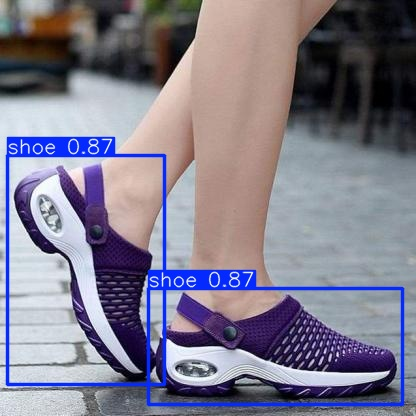

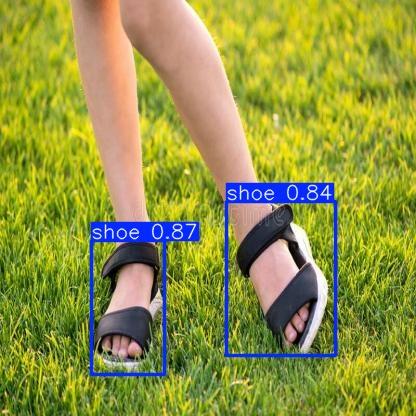

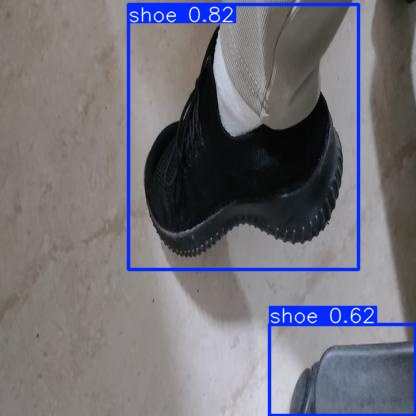

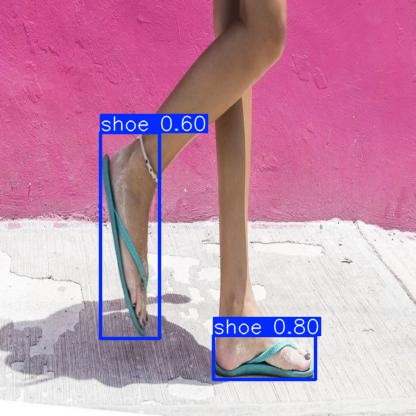

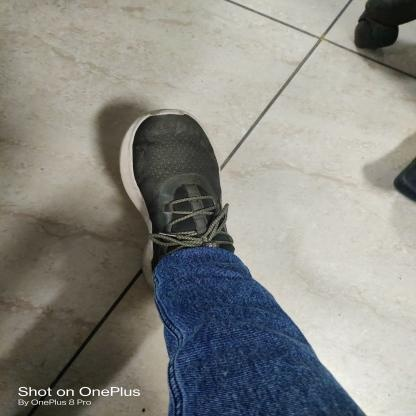

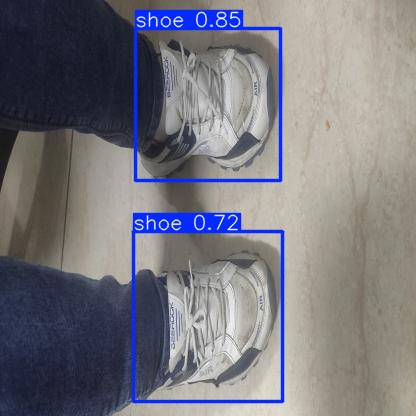

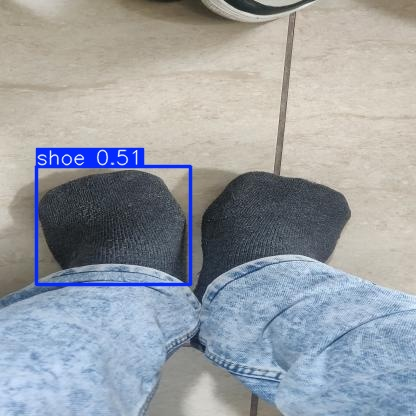

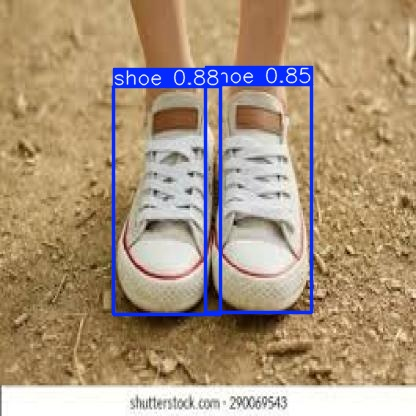

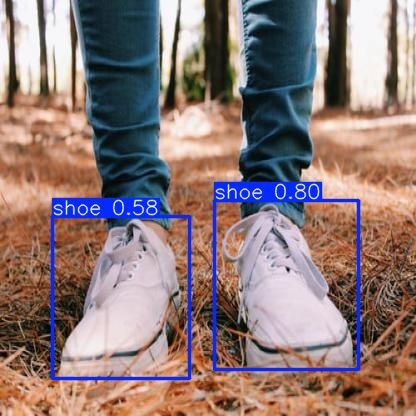

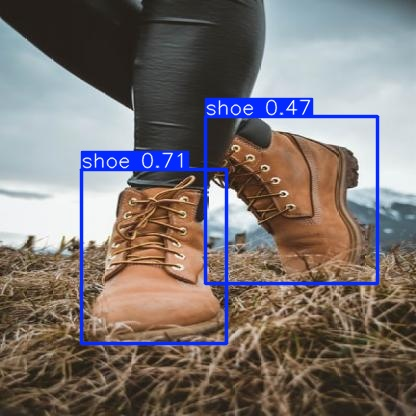

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

##6. Export and download model

First, zip and download the trained model by running the code blocks below.

The code creates a folder named `my_model`, moves the model weights into it, and renames them from `best.pt` to `my_model.pt`. It also adds the training results in case you want to reference them later.

In [ ]:
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model
!rm -rf /content/my_model/weights

It then zips the folder as `my_model.zip`.

In [ ]:
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 8%)
  adding: train/ (stored 0%)
  adding: train/train_batch3200.jpg (deflated 11%)
  adding: train/BoxPR_curve.png (deflated 22%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/best.pt (deflated 8%)
  adding: train/weights/last.pt (deflated 8%)
  adding: train/val_batch1_pred.jpg (deflated 5%)
  adding: train/confusion_matrix.png (deflated 37%)
  adding: train/train_batch1.jpg (deflated 5%)
  adding: train/train_batch0.jpg (deflated 5%)
  adding: train/confusion_matrix_normalized.png (deflated 36%)
  adding: train/labels.jpg (deflated 26%)
  adding: train/results.png (deflated 7%)
  adding: train/args.yaml (deflated 53%)
  adding: train/BoxF1_curve.png (deflated 16%)
  adding: train/train_batch3201.jpg (deflated 11%)
  adding: train/BoxR_curve.png (deflated 15%)
  adding: train/val_batch2_labels.jpg (deflated 14%)
  adding: train/results.csv (deflated 60%)
  adding: train/train_batch2.jpg (deflated 5%)
  adding: train/Box

Then download the `my_model.zip` file to your local computer by executing the following code block. You can also download it drirectly from the sidebar.

In [ ]:
from google.colab import files

files.download('/content/my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Appendix: Common Errors

If you run into any errors working through this notebook, please do the following:

- Double-check that the dataset files are set up in the correct folder structure
- Make sure there are no typos or errors in your labelmap file
- Google search the error to look for solutions

If none of those help, please submit an [Issue](https://github.com/YGOhappy123/Saigon-Steps-AI-Training/issues) on the GitHub page. In this section, I will add resolutions to common errors as they come up.